# Глава 4. Датасет с текстовыми данными
## SMS Spam Collection Dataset
**Задача:** бинарная классификация SMS-сообщений (spam / ham)  
**Источник:** https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

---
## Ячейка 1. Монтирование Google Drive и загрузка датасета
Положите файл `spam.csv` в папку `Course_project/` на Google Drive.

In [ ]:
from google.colab import drive
import os, zipfile

drive.mount('/content/drive')

project_dir = '/content/drive/MyDrive/Course_project/'
csv_path = os.path.join(project_dir, 'spam.csv')

if not os.path.exists(csv_path):
    raise FileNotFoundError(f'Файл spam.csv не найден в {project_dir}')

print(f'Файл найден: {csv_path}')

Mounted at /content/drive
Файл найден: /content/drive/MyDrive/Course_project/spam.csv


---
## Ячейка 2. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
import os
from collections import Counter

# NLP
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# Wordcloud
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
except ImportError:
    WC_AVAILABLE = False
    print('wordcloud не установлен: pip install wordcloud')

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
SPAM_COLOR = '#E74C3C'
HAM_COLOR  = '#1ABC9C'

# Папка для сохранения рисунков
OUT_DIR = '/content/figures'
os.makedirs(OUT_DIR, exist_ok=True)

print('Все библиотеки импортированы.')

Все библиотеки импортированы.


---
## Ячейка 3. Загрузка исходного файла
Загружаем `spam.csv`, изучаем структуру до предобработки.

In [ ]:
df_raw = pd.read_csv(csv_path, encoding='latin-1', header=0)
print('=== Исходный датасет ===')
print(f'Размер: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов')
print(f'Столбцы: {list(df_raw.columns)}')
print()

# Таблица пропусков (Таблица 4.2)
miss = df_raw.isnull().sum()
total_cells = df_raw.shape[0] * df_raw.shape[1]
total_miss  = miss.sum()
print('=== Таблица 4.2. Пропущенные значения по столбцам ===')
miss_df = pd.DataFrame({'Столбец': miss.index, 'Пропусков': miss.values})
print(miss_df.to_string(index=False))
print(f'\nВсего пропусков: {total_miss} ({total_miss/total_cells*100:.2f}% от всех ячеек)')
print()
print('=== Первые 5 строк (Рисунок 4.1) ===')
display(df_raw.head())

=== Исходный датасет ===
Размер: 5572 строк, 5 столбцов
Столбцы: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

=== Таблица 4.2. Пропущенные значения по столбцам ===
   Столбец  Пропусков
        v1          0
        v2          0
Unnamed: 2       5522
Unnamed: 3       5560
Unnamed: 4       5566

Всего пропусков: 16648 (59.76% от всех ячеек)

=== Первые 5 строк (Рисунок 4.1) ===


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


---
## Ячейка 4. Удаление пропусков и лишних столбцов

In [ ]:
# Оставляем только столбцы v1 и v2, переименовываем
df = df_raw[['v1', 'v2']].copy()
df.columns = ['label', 'text']

# Удаляем строки с любыми пропусками
before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'Строк до очистки:  {before}')
print(f'Строк после очистки: {after}')
print(f'Удалено строк: {before - after}')
print(f'\nРаспределение классов:')
print(df['label'].value_counts())
print()
print('=== Первые 5 строк spam_cleaned.csv (Рисунок 4.2) ===')
display(df.head())

# Сохраняем
df.to_csv('/content/spam_cleaned.csv', index=False)
print('\nСохранён: /content/spam_cleaned.csv')

Строк до очистки:  5572
Строк после очистки: 5572
Удалено строк: 0

Распределение классов:
label
ham     4825
spam     747
Name: count, dtype: int64

=== Первые 5 строк spam_cleaned.csv (Рисунок 4.2) ===


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Сохранён: /content/spam_cleaned.csv


---
## Ячейка 5. Удаление персональных данных

In [ ]:
import re

def remove_pii(text):
    """Полностью удаляет email, номера телефонов и уже существующие [REMOVED]."""
    # Удаляем уже существующие [REMOVED]
    text = re.sub(r'\[REMOVED\]', '', text)

    # Email
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.]+', '', text)

    # Телефоны (разные форматы)
    text = re.sub(r'\+?\d[\d\s\-().]{7,}\d', '', text)

    # Короткие номера (5-6 цифр)
    text = re.sub(r'\b\d{5,6}\b', '', text)

    # Убираем двойные и более пробелы + trim
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Применяем очистку
df['text'] = df['text'].apply(remove_pii)

# Проверка
examples = df[df['text'].str.contains(r'\d{4,}|\@', na=False, regex=True)].head(5)

print('Примеры строк после удаления PII:')
for _, row in examples.iterrows():
    print(f'[{row["label"]}] {row["text"][:200]}...')

print('\n=== Первые 5 строк после очистки ===')
display(df.head())

df.to_csv('/content/spam_pii_removed.csv', index=False)
print('\nФайл сохранён: /content/spam_pii_removed.csv')

Примеры строк после удаления PII:
[spam] Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to to receive entry question(std txt rate)T&C's apply over18's...
[spam] URGENT! You have won a 1 week FREE membership in our å£100,000 Prize Jackpot! Txt the word: CLAIM to No: T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18...
[spam] England v Macedonia - dont miss the goals/team news. Txt ur national team to eg ENGLAND to Try:WALES, SCOTLAND 4txt/Ì¼1.20 POBOXox36504W45WQ 16+...
[ham] Do you know what Mallika Sherawat did yesterday? Find out now @ &lt;URL&gt;...
[spam] As a valued customer, I am pleased to advise you that following recent review of your Mob No. you are awarded with a å£1500 Bonus Prize, call...

=== Первые 5 строк после очистки ===


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Файл сохранён: /content/spam_pii_removed.csv


---
## Ячейка 6. Балансировка классов

=== Рисунок 4.4: распределение ДО балансировки ===


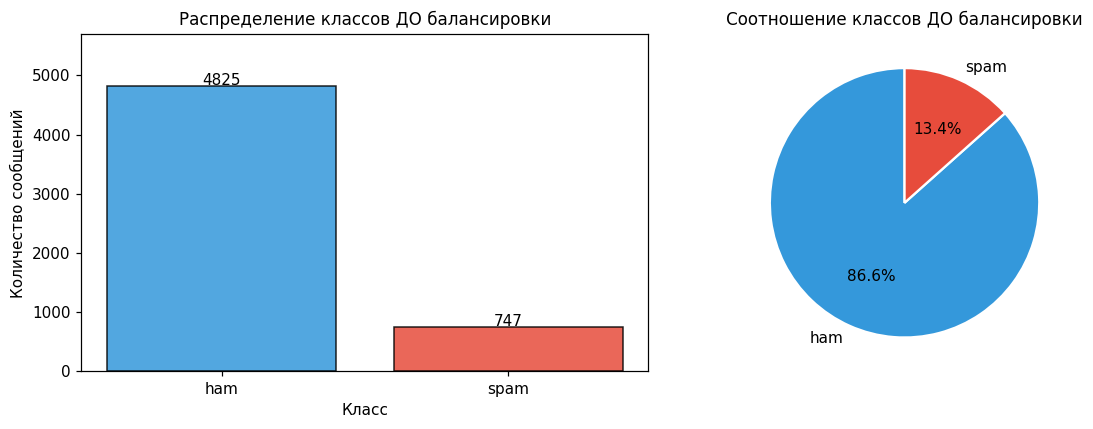

Сохранён: fig_4_4_before_balance.png

После балансировки: 1494 сообщений (747 spam + 747 ham)

=== Рисунок 4.5: распределение ПОСЛЕ балансировки ===


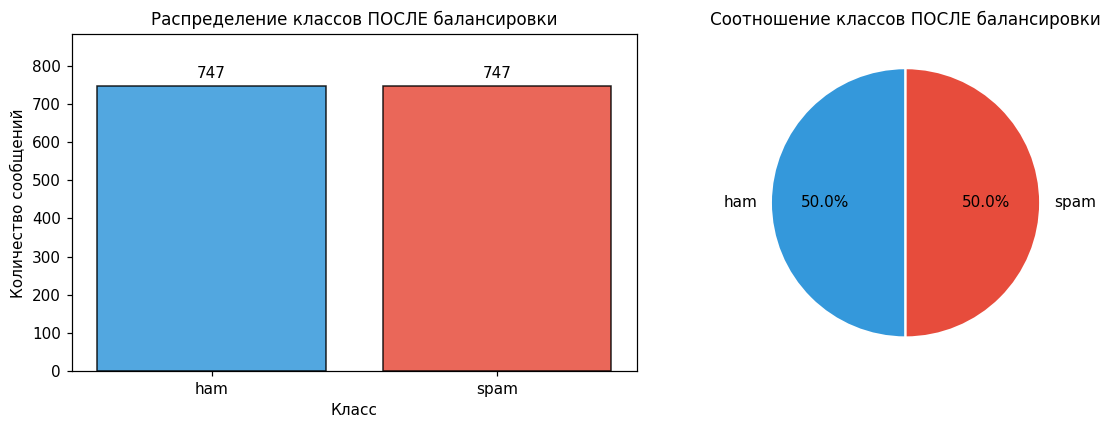

Сохранён: fig_4_5_after_balance.png
Сохранён: /content/spam_balanced.csv


In [ ]:
SPAM_COLOR = '#e74c3c'   # красный
HAM_COLOR = '#3498db'    # синий
def plot_class_distribution(df, title_bar, title_pie, colors, filename):
    counts = df['label'].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Столбчатая диаграмма
    bars = axes[0].bar(counts.index, counts.values,
                       color=[SPAM_COLOR if x=='spam' else HAM_COLOR for x in counts.index],
                       edgecolor='black', alpha=0.85)
    axes[0].set_title(title_bar, fontsize=11)
    axes[0].set_xlabel('Класс')
    axes[0].set_ylabel('Количество сообщений')
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     str(val), ha='center', fontsize=10)
    axes[0].set_ylim(0, counts.max() * 1.18)

    # Круговая диаграмма
    wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
    pie_colors = [SPAM_COLOR if x=='spam' else HAM_COLOR for x in counts.index]
    axes[1].pie(counts.values, labels=counts.index,
                colors=pie_colors, autopct='%1.1f%%',
                startangle=90, wedgeprops=wedge_props)
    axes[1].set_title(title_pie, fontsize=11)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), bbox_inches='tight')
    plt.show()
    print(f'Сохранён: {filename}')

# До балансировки
print('=== Рисунок 4.4: распределение ДО балансировки ===')
plot_class_distribution(df,
    'Распределение классов ДО балансировки',
    'Соотношение классов ДО балансировки',
    ['#e74c3c', '#3498db'], 'fig_4_4_before_balance.png')

# Undersampling: оставляем min(spam, ham) примеров каждого класса
n_min = df['label'].value_counts().min()
df_spam = df[df['label']=='spam'].sample(n=n_min, random_state=42)
df_ham  = df[df['label']=='ham'].sample(n=n_min, random_state=42)
df_bal  = pd.concat([df_spam, df_ham]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nПосле балансировки: {len(df_bal)} сообщений ({n_min} spam + {n_min} ham)')

# После балансировки
print('\n=== Рисунок 4.5: распределение ПОСЛЕ балансировки ===')
plot_class_distribution(df_bal,
    'Распределение классов ПОСЛЕ балансировки',
    'Соотношение классов ПОСЛЕ балансировки',
    ['#e74c3c', '#3498db'], 'fig_4_5_after_balance.png')

df_bal.to_csv('/content/spam_balanced.csv', index=False)
print('Сохранён: /content/spam_balanced.csv')

---
## Ячейка 7. Очистка текста — нижний регистр и пунктуация

In [ ]:
def clean_text(text):
    """Приводит к нижнему регистру, удаляет знаки препинания и цифры."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # оставляем только буквы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_bal['text'] = df_bal['text'].apply(clean_text)
df_bal.to_csv('/content/spam_lreg.csv', index=False)

print('=== Рисунок 4.6: spam_lreg.csv (первые 5 строк) ===')
display(df_bal.head())

# Пример трансформации
print('\n=== Таблица 4.3: пример изменения текста ===')
sample = df_bal.iloc[0]
print(f'После очистки: {sample["text"][:100]}...')

=== Рисунок 4.6: spam_lreg.csv (первые 5 строк) ===


,label,text
0,ham,come to mu we re sorting out our narcotics sit...
1,ham,we can go e normal pilates after our intro
2,ham,have you laid your airtel line to rest
3,ham,gokila is talking with you aha
4,ham,we confirm eating at esplanade



=== Таблица 4.3: пример изменения текста ===
После очистки: come to mu we re sorting out our narcotics situation...


---
## Ячейка 8. Лемматизация (Рисунок 4.7)

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """Лемматизирует каждое слово строки."""
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split())

df_bal['text'] = df_bal['text'].apply(lemmatize_text)
df_bal.to_csv('/content/spam_lemmatized.csv', index=False)

print('=== Рисунок 4.7: spam_lemmatized.csv (первые 5 строк) ===')
display(df_bal.head())

# Таблица 4.3: примеры трансформации
df_raw_sample = pd.read_csv(csv_path, encoding='latin-1', header=0)
df_raw_sample = df_raw_sample[['v1','v2']].dropna()
df_raw_sample.columns = ['label','text']

print('\n=== Таблица 4.3: трансформация примеров ===')
for i in range(min(3, len(df_bal))):
    orig = df_raw_sample['text'].iloc[i] if i < len(df_raw_sample) else ''
    proc = df_bal['text'].iloc[i]
    lbl  = df_bal['label'].iloc[i]
    print(f'\nПример {i+1} [{lbl}]:')
    print(f'  Оригинал:       {str(orig)[:100]}')
    print(f'  После обработки: {proc[:100]}')

=== Рисунок 4.7: spam_lemmatized.csv (первые 5 строк) ===


,label,text
0,ham,come to mu we re sorting out our narcotic situ...
1,ham,we can go e normal pilate after our intro
2,ham,have you laid your airtel line to rest
3,ham,gokila is talking with you aha
4,ham,we confirm eating at esplanade



=== Таблица 4.3: трансформация примеров ===

Пример 1 [ham]:
  Оригинал:       Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a
  После обработки: come to mu we re sorting out our narcotic situation

Пример 2 [ham]:
  Оригинал:       Ok lar... Joking wif u oni...
  После обработки: we can go e normal pilate after our intro

Пример 3 [ham]:
  Оригинал:       Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr
  После обработки: have you laid your airtel line to rest


---
## Ячейка 9. Частотный анализ — топ-10 слов и Word Cloud

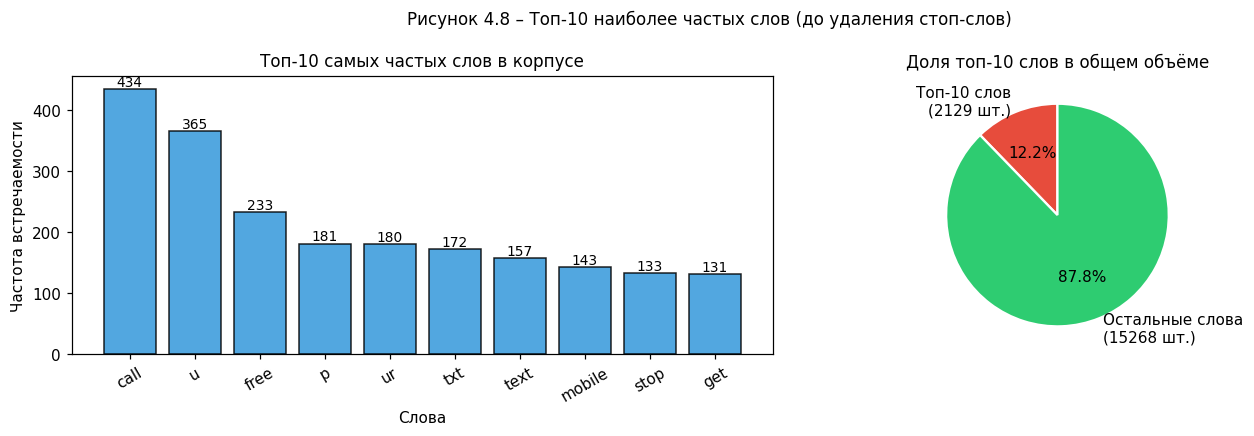

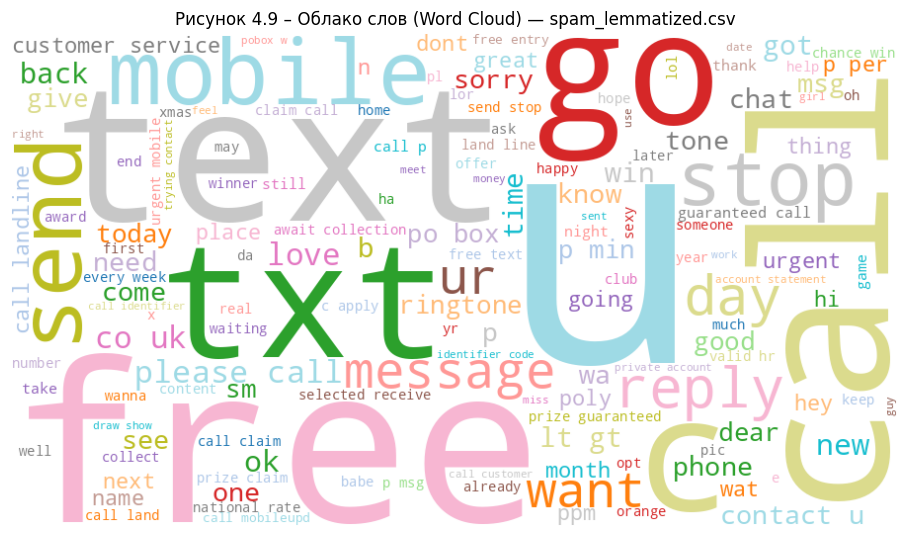

In [ ]:
def get_top_words(series, n=10):
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(n)

top_before = get_top_words(df_bal['text'])
words_b, counts_b = zip(*top_before)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Столбчатая диаграмма
axes[0].bar(words_b, counts_b, color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Топ-10 самых частых слов в корпусе', fontsize=11)
axes[0].set_xlabel('Слова')
axes[0].set_ylabel('Частота встречаемости')
for i, (w, c) in enumerate(zip(words_b, counts_b)):
    axes[0].text(i, c + 5, str(c), ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Круговая диаграмма: доля топ-10
total_words = sum(Counter(' '.join(df_bal['text']).split()).values())
top10_sum = sum(counts_b)
rest = total_words - top10_sum
axes[1].pie([top10_sum, rest],
            labels=[f'Топ-10 слов\n({top10_sum} шт.)', f'Остальные слова\n({rest} шт.)'],
            colors=['#e74c3c','#2ecc71'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Доля топ-10 слов в общем объёме', fontsize=11)

plt.suptitle('Рисунок 4.8 – Топ-10 наиболее частых слов (до удаления стоп-слов)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_4_8_top10_before_sw.png'), bbox_inches='tight')
plt.show()

# Word Cloud (Рисунок 4.9)
if WC_AVAILABLE:
    corpus_text = ' '.join(df_bal['text'])
    wc = WordCloud(width=900, height=500, background_color='white',
                   colormap='tab20', max_words=150).generate(corpus_text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Рисунок 4.9 – Облако слов (Word Cloud) — spam_lemmatized.csv', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'fig_4_9_wordcloud_before_sw.png'), bbox_inches='tight')
    plt.show()
else:
    print('Word Cloud недоступен. Установите: !pip install wordcloud')

---
## Ячейка 10. Удаление стоп-слов и повторный анализ

=== Рисунок 4.10: spam_no_stopwords.csv (первые 5 строк) ===


,label,text
0,ham,come mu sorting narcotic situation
1,ham,go e normal pilate intro
2,ham,laid airtel line rest
3,ham,gokila talking aha
4,ham,confirm eating esplanade


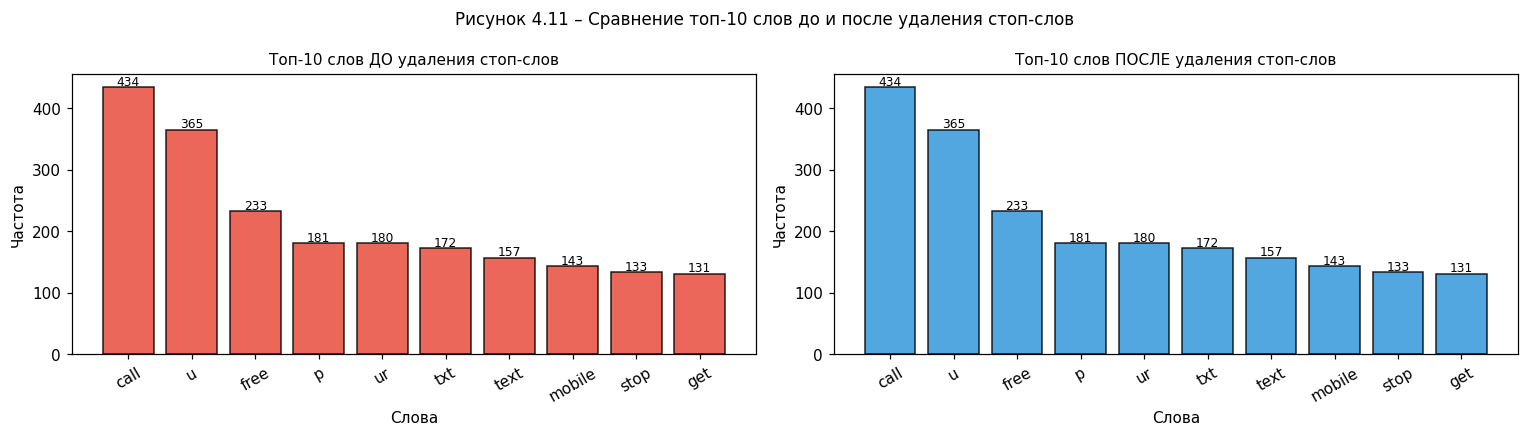

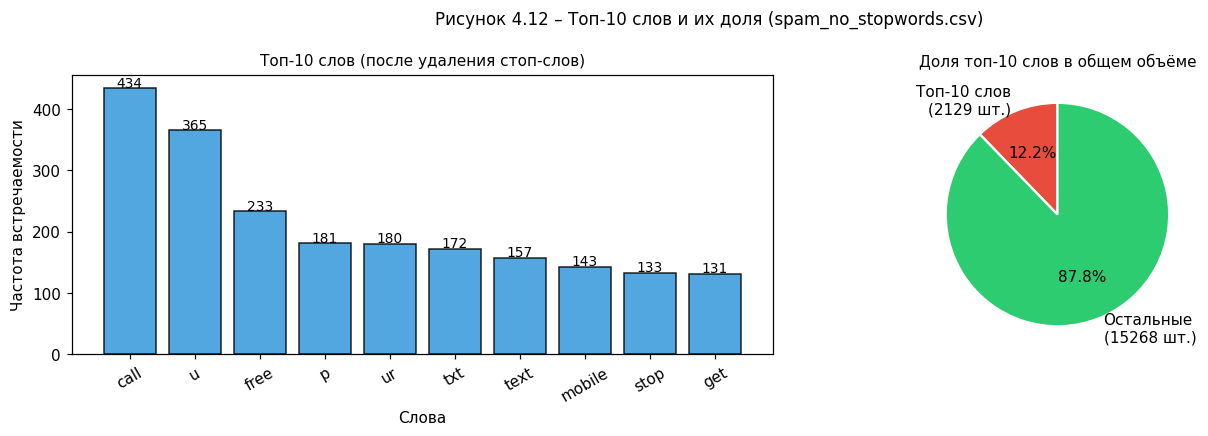

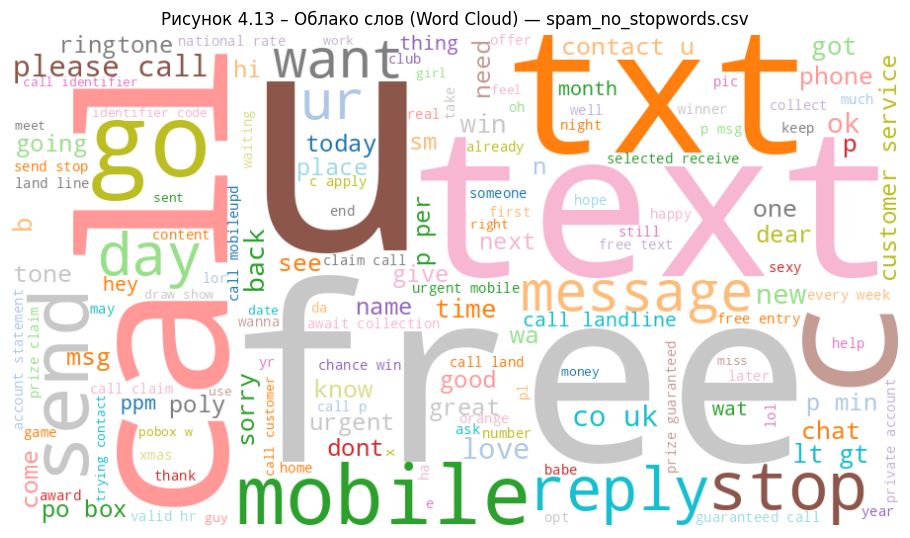

In [ ]:
STOP_WORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in STOP_WORDS)

df_bal['text'] = df_bal['text'].apply(remove_stopwords)
df_bal.to_csv('/content/spam_no_stopwords.csv', index=False)

print('=== Рисунок 4.10: spam_no_stopwords.csv (первые 5 строк) ===')
display(df_bal.head())

# --- Рисунок 4.11: сравнение топ-10 до и после ---
top_after = get_top_words(df_bal['text'])
words_a, counts_a = zip(*top_after)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(words_b, counts_b, color=SPAM_COLOR, edgecolor='black', alpha=0.85)
axes[0].set_title('Топ-10 слов ДО удаления стоп-слов', fontsize=10)
axes[0].set_xlabel('Слова'); axes[0].set_ylabel('Частота')
axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(words_a, counts_a, color=HAM_COLOR, edgecolor='black', alpha=0.85)
axes[1].set_title('Топ-10 слов ПОСЛЕ удаления стоп-слов', fontsize=10)
axes[1].set_xlabel('Слова'); axes[1].set_ylabel('Частота')
axes[1].tick_params(axis='x', rotation=30)
for ax, wds, cts in [(axes[0], words_b, counts_b), (axes[1], words_a, counts_a)]:
    for i, (w, c) in enumerate(zip(wds, cts)):
        ax.text(i, c + 3, str(c), ha='center', fontsize=8)
plt.suptitle('Рисунок 4.11 – Сравнение топ-10 слов до и после удаления стоп-слов', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_4_11_top10_compare.png'), bbox_inches='tight')
plt.show()

# --- Рисунок 4.12: детальные диаграммы после ---
total_after = sum(Counter(' '.join(df_bal['text']).split()).values())
top10_after_sum = sum(counts_a)
rest_after = total_after - top10_after_sum

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(words_a, counts_a, color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Топ-10 слов (после удаления стоп-слов)', fontsize=10)
axes[0].set_xlabel('Слова'); axes[0].set_ylabel('Частота встречаемости')
axes[0].tick_params(axis='x', rotation=30)
for i, (w, c) in enumerate(zip(words_a, counts_a)):
    axes[0].text(i, c + 2, str(c), ha='center', fontsize=9)
axes[1].pie([top10_after_sum, rest_after],
            labels=[f'Топ-10 слов\n({top10_after_sum} шт.)',
                    f'Остальные\n({rest_after} шт.)'],
            colors=['#e74c3c','#2ecc71'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Доля топ-10 слов в общем объёме', fontsize=10)
plt.suptitle('Рисунок 4.12 – Топ-10 слов и их доля (spam_no_stopwords.csv)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_4_12_top10_after_sw.png'), bbox_inches='tight')
plt.show()

# --- Рисунок 4.13: Word Cloud после ---
if WC_AVAILABLE:
    corpus_clean = ' '.join(df_bal['text'])
    wc2 = WordCloud(width=900, height=500, background_color='white',
                    colormap='tab20', max_words=150).generate(corpus_clean)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc2, interpolation='bilinear')
    plt.axis('off')
    plt.title('Рисунок 4.13 – Облако слов (Word Cloud) — spam_no_stopwords.csv', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'fig_4_13_wordcloud_after_sw.png'), bbox_inches='tight')
    plt.show()

---
## Ячейка 11. TF-IDF векторизация

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df_bal['text'])
vocab = vectorizer.vocabulary_
idf_values = vectorizer.idf_

# Словарь слово → IDF
idf_df = pd.DataFrame({
    'word': list(vocab.keys()),
    'idf':  [idf_values[i] for i in vocab.values()]
}).sort_values('word').reset_index(drop=True)

print(f'Размер матрицы TF-IDF: {tfidf_matrix.shape}')
print(f'  строк (сообщений): {tfidf_matrix.shape[0]}')
print(f'  столбцов (слов в словаре): {tfidf_matrix.shape[1]}')
print(f'Максимальное значение IDF: {idf_values.max():.4f}')
print(f'Минимальное значение IDF: {idf_values.min():.4f}')
print()
print('=== Рисунок 4.14: фрагмент словаря с IDF (отсортирован по алфавиту) ===')
display(idf_df.head(15))

# Пример первого вектора
first_vec = tfidf_matrix[0]
nonzero  = first_vec.nnz
density  = nonzero / tfidf_matrix.shape[1] * 100
print(f'\n=== Пример: первое сообщение ===')
print(f'Метка:            {df_bal["label"].iloc[0]}')
print(f'Текст:            {df_bal["text"].iloc[0][:90]}...')
print(f'Размер вектора:   {tfidf_matrix.shape[1]}')
print(f'Ненулевых значений: {nonzero}')
print(f'Плотность вектора:  {density:.4f}%')

Размер матрицы TF-IDF: (1494, 3319)
  строк (сообщений): 1494
  столбцов (слов в словаре): 3319
Максимальное значение IDF: 7.6167
Минимальное значение IDF: 2.3723

=== Рисунок 4.14: фрагмент словаря с IDF (отсортирован по алфавиту) ===


,word,idf
0,ab,7.616734
1,aberdeen,7.616734
2,abi,7.616734
3,able,7.211269
4,aboutas,7.616734
5,abroad,7.616734
6,absolutely,7.616734
7,abstract,7.616734
8,abt,6.700444
9,abta,6.923587



=== Пример: первое сообщение ===
Метка:            ham
Текст:            come mu sorting narcotic situation...
Размер вектора:   3319
Ненулевых значений: 5
Плотность вектора:  0.1506%


---
## Ячейка 12. Информационный поиск по корпусу

In [ ]:
def search_corpus(query, df, vectorizer, tfidf_matrix, top_n=3):
    """Ищет top_n наиболее похожих сообщений на запрос по косинусному сходству."""
    # Предобрабатываем запрос так же, как и корпус
    q = query.lower()
    q = re.sub(r'[^a-z\s]', ' ', q)
    q = ' '.join(lemmatizer.lemmatize(w) for w in q.split()
                 if w not in STOP_WORDS)
    print(f'  Запрос после очистки: "{q}"')
    q_vec = vectorizer.transform([q])
    sims  = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_idx = sims.argsort()[::-1][:top_n]
    for rank, idx in enumerate(top_idx, 1):
        label = df['label'].iloc[idx]
        text  = df['text'].iloc[idx]
        print(f'  {rank}. Сходство: {sims[idx]:.6f} | {label} | {text[:80]}...')

queries = ['winner', 'urgent', 'free call', 'congratulations']
print('=' * 60)
print('Рисунок 4.15 – Результаты информационного поиска')
print('=' * 60)
for q in queries:
    print(f'\n--- ТЕСТ: "{q}" ---')
    search_corpus(q, df_bal, vectorizer, tfidf_matrix)

Рисунок 4.15 – Результаты информационного поиска

--- ТЕСТ: "winner" ---
  Запрос после очистки: "winner"
  1. Сходство: 0.367026 | spam | congratulation winner august prize draw call prize code...
  2. Сходство: 0.310703 | spam | winner specially selected receive cash award speak live operator claim call pm c...
  3. Сходство: 0.310703 | spam | winner specially selected receive cash award speak live operator claim call pm c...

--- ТЕСТ: "urgent" ---
  Запрос после очистки: "urgent"
  1. Сходство: 0.365403 | spam | please call immediately urgent message waiting...
  2. Сходство: 0.365403 | spam | please call immediately urgent message waiting...
  3. Сходство: 0.365403 | spam | please call immediately urgent message waiting...

--- ТЕСТ: "free call" ---
  Запрос после очистки: "free call"
  1. Сходство: 0.505203 | ham | sir waiting call free please call...
  2. Сходство: 0.504683 | ham | free call pa...
  3. Сходство: 0.486364 | spam | want new nokia colour phone deliveredtomorrow fre

---
## Ячейка 13. Распределение длин текстов

Среднее (все):  98.9 симв., медиана: 110 симв.
Среднее spam:   128.8 симв.
Среднее ham:    69.0 симв.


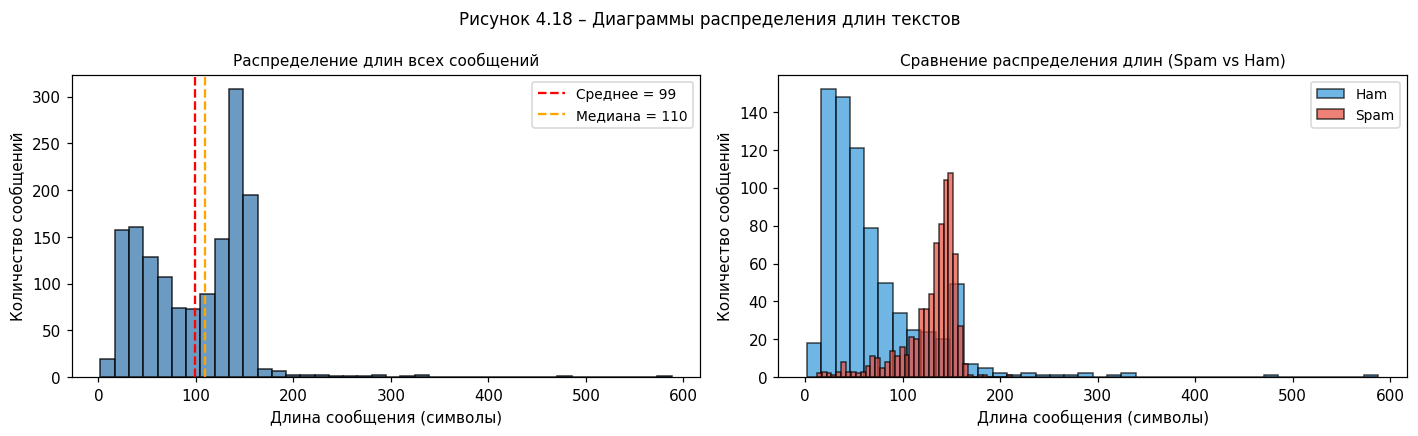

In [ ]:
# Считаем длины по исходным текстам (до лемматизации) — из spam_cleaned.csv
df_for_len = pd.read_csv('/content/spam_balanced.csv')
df_for_len['length'] = df_for_len['text'].astype(str).apply(len)

spam_len = df_for_len[df_for_len['label']=='spam']['length']
ham_len  = df_for_len[df_for_len['label']=='ham']['length']
all_len  = df_for_len['length']

print(f'Среднее (все):  {all_len.mean():.1f} симв., медиана: {all_len.median():.0f} симв.')
print(f'Среднее spam:   {spam_len.mean():.1f} симв.')
print(f'Среднее ham:    {ham_len.mean():.1f} симв.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Все сообщения
axes[0].hist(all_len, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(all_len.mean(),   color='red',    linestyle='--', label=f'Среднее = {all_len.mean():.0f}')
axes[0].axvline(all_len.median(), color='orange', linestyle='--', label=f'Медиана = {all_len.median():.0f}')
axes[0].set_title('Распределение длин всех сообщений', fontsize=10)
axes[0].set_xlabel('Длина сообщения (символы)')
axes[0].set_ylabel('Количество сообщений')
axes[0].legend(fontsize=9)

# По классам
axes[1].hist(ham_len,  bins=40, color=HAM_COLOR,  edgecolor='black', alpha=0.7, label='Ham')
axes[1].hist(spam_len, bins=40, color=SPAM_COLOR, edgecolor='black', alpha=0.7, label='Spam')
axes[1].set_title('Сравнение распределения длин (Spam vs Ham)', fontsize=10)
axes[1].set_xlabel('Длина сообщения (символы)')
axes[1].set_ylabel('Количество сообщений')
axes[1].legend(fontsize=9)

plt.suptitle('Рисунок 4.18 – Диаграммы распределения длин текстов', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_4_18_text_lengths.png'), bbox_inches='tight')
plt.show()

---
## Ячейка 14. Разбивка на train / val / test

In [ ]:
# Разбиваем: 70% train, 15% val, 15% test
X = df_bal['text'].values
y = df_bal['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

train_df = pd.DataFrame({'label': y_train, 'text': X_train})
val_df   = pd.DataFrame({'label': y_val,   'text': X_val})
test_df  = pd.DataFrame({'label': y_test,  'text': X_test})

os.makedirs('/content/data', exist_ok=True)
train_df.to_csv('/content/data/train.csv', index=False)
val_df.to_csv('/content/data/val.csv',     index=False)
test_df.to_csv('/content/data/test.csv',   index=False)

# Таблица 4.4
print('=== Таблица 4.4. Параметры разбивки датасета ===')
for name, df_s in [('train (70%)', train_df), ('val (15%)', val_df), ('test (15%)', test_df)]:
    sp = (df_s['label']=='spam').sum()
    hm = (df_s['label']=='ham').sum()
    print(f'  {name:12s}: {len(df_s):4d} сообщений  |  spam: {sp}  |  ham: {hm}')
print(f'  {"Итого":12s}: {len(df_bal):4d} сообщений  |  spam: {(df_bal["label"]=="spam").sum()}  |  ham: {(df_bal["label"]=="ham").sum()}')

# Структура каталогов (Рисунок 4.16)
print('\n=== Рисунок 4.16: структура каталогов ===')
for f in ['/content/data/train.csv', '/content/data/val.csv', '/content/data/test.csv']:
    print(f'  {f}')

# Вид train.csv (Рисунок 4.17)
print('\n=== Рисунок 4.17: вид файла train.csv ===')
display(train_df.head(10))

=== Таблица 4.4. Параметры разбивки датасета ===
  train (70%) : 1045 сообщений  |  spam: 523  |  ham: 522
  val (15%)   :  224 сообщений  |  spam: 112  |  ham: 112
  test (15%)  :  225 сообщений  |  spam: 112  |  ham: 113
  Итого       : 1494 сообщений  |  spam: 747  |  ham: 747

=== Рисунок 4.16: структура каталогов ===
  /content/data/train.csv
  /content/data/val.csv
  /content/data/test.csv

=== Рисунок 4.17: вид файла train.csv ===


,label,text
0,ham,dun cut short leh u dun like ah failed quite sad
1,spam,hi amy sending free phone number couple day gi...
2,ham,well keep mind got enough gas one round trip b...
3,spam,double min txts month free bluetooth orange av...
4,ham,cant pick phone right pls send message
5,spam,discount code rp stop message reply stop www r...
6,ham,poking man everyday teach canada abi saying hi
7,spam,urgent costa del sol holiday await collection ...
8,ham,dun need pick ur gf
9,spam,valentine day special win quiz take partner tr...
